# Projeto Final — RNA e Deep Learning

## Classificação de Pistaches com Rede Neural (sem Convolução)

---

**Integrante (trabalho individual):**

| Nome | E-mail |
|------|--------|
| Caio Augustus Lima de Abreu Monteiro | calam@cesar.school |

**Dataset escolhido:** Pistachio Dataset

**Link:** https://www.kaggle.com/datasets/muratkokludataset/pistachio-dataset

---

**CESAR School** — Especialização em Engenharia e Análise de Dados (Turma 2025.2)<br>
**Docente:** Vitor Casadei


## 1. Descrição do problema e do dataset

O **Pistachio Dataset** (Koklu et al.) reúne medidas morfológicas extraídas de imagens de duas variedades de pistache cultivadas na Turquia: *Kirmizi* e *Siirt*. O objetivo é, a partir dessas medidas, classificar a qual das duas variedades cada amostra pertence — um problema de **classificação binária**.

Utiliza-se aqui a versão tabular com **16 atributos numéricos** (`Pistachio_16_Features_Dataset.xlsx`), que descrevem características geométricas dos grãos, tais como área, perímetro, eixos maior e menor, excentricidade, solidez e diversos fatores de forma. Por se tratar de dados tabulares de dimensão reduzida, uma **rede neural densa (MLP)**, sem qualquer camada convolucional, é adequada e suficiente para resolver o problema, em conformidade com os requisitos do projeto.

> **Observação sobre a execução.** Este notebook lê o arquivo `Pistachio_16_Features_Dataset.xlsx`. Para executá-lo no Google Colab, basta enviar o arquivo ao ambiente (por exemplo, via `files.upload()` ou montando o Google Drive) e ajustar a variável `CAMINHO_DATASET` para o local correspondente. O arquivo faz parte do ZIP disponibilizado na página do dataset no Kaggle.

## 2. Importação das bibliotecas


In [18]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

Dispositivo: cpu


## 3. Carregamento e preparação dos dados


### 3.1. Leitura do dataset


In [19]:
# Download do dataset diretamente do Kaggle (API pública)
!curl -L -o /content/pistachio.zip https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/pistachio-dataset
!unzip -o /content/pistachio.zip -d /content/pistachio

# Caminho do arquivo de 16 features dentro da estrutura extraída
CAMINHO_DATASET = '/content/pistachio/Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.xlsx'

df = pd.read_excel(CAMINHO_DATASET)
print('Dimensões do dataset:', df.shape)
print('Valores ausentes:', df.isnull().sum().sum())
df.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1859k  100 1859k    0     0  4108k      0 --:--:-- --:--:-- --:--:-- 4108k
Archive:  /content/pistachio.zip
  inflating: /content/pistachio/Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.arff  
  inflating: /content/pistachio/Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.xls  
  inflating: /content/pistachio/Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.xlsx  
  inflating: /content/pistachio/Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset_Citation_Request.txt  
  inflating: /content/pistachio/Pistachio_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.arff  
  inflating: /content/pistachio/Pistachio_Dataset/P

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,ROUNDNESS,COMPACTNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,SHAPEFACTOR_4,Class
0,63391,1568.405,390.3396,236.7461,0.7951,284.0984,0.8665,73160,0.6394,1.6488,0.3238,0.7278,0.0062,0.0037,0.5297,0.8734,Kirmizi_Pistachio
1,68358,1942.187,410.8594,234.7525,0.8207,295.0188,0.8765,77991,0.6772,1.7502,0.2277,0.7181,0.0060,0.0034,0.5156,0.9024,Kirmizi_Pistachio
2,73589,1246.538,452.3630,220.5547,0.8731,306.0987,0.9172,80234,0.7127,2.0510,0.5951,0.6767,0.0061,0.0030,0.4579,0.9391,Kirmizi_Pistachio
3,71106,1445.261,429.5291,216.0765,0.8643,300.8903,0.9589,74153,0.7028,1.9879,0.4278,0.7005,0.0060,0.0030,0.4907,0.9755,Kirmizi_Pistachio
4,80087,1251.524,469.3783,220.9344,0.8823,319.3273,0.9657,82929,0.7459,2.1245,0.6425,0.6803,0.0059,0.0028,0.4628,0.9833,Kirmizi_Pistachio


### 3.2. Análise exploratória


Verifica-se a distribuição das classes e as estatísticas descritivas dos atributos. O dataset apresenta um leve desbalanceamento entre as duas variedades, o que será considerado na divisão dos dados (amostragem estratificada) e na interpretação das métricas.

Class
Kirmizi_Pistachio    1232
Siit_Pistachio        916
Name: count, dtype: int64

Proporção:
Class
Kirmizi_Pistachio    0.574
Siit_Pistachio       0.426
Name: count, dtype: float64


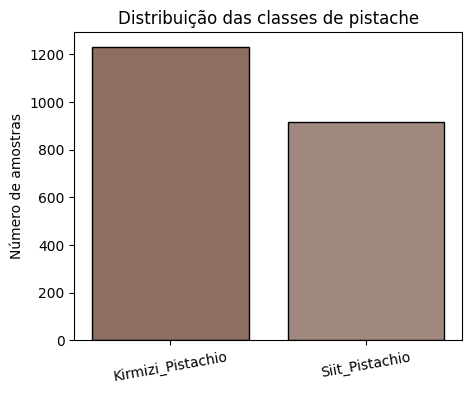

In [20]:
# Distribuição das classes
contagem = df['Class'].value_counts()
print(contagem)
print('\nProporção:')
print((contagem / len(df)).round(3))

plt.figure(figsize=(5, 4))
plt.bar(contagem.index, contagem.values, color=['#8d6e63', '#a1887f'], edgecolor='k')
plt.ylabel('Número de amostras')
plt.title('Distribuição das classes de pistache')
plt.xticks(rotation=10)
plt.show()

In [21]:
# Estatísticas descritivas dos atributos
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AREA,2148.0,79950.655493,13121.737799,29808.0000,71936.750000,79905.50000,89030.500000,124008.0000
PERIMETER,2148.0,1425.971751,375.565503,858.3630,1170.996250,1262.78550,1607.906250,2755.0491
MAJOR_AXIS,2148.0,446.248968,32.445304,320.3445,426.508750,448.57475,468.509400,541.9661
MINOR_AXIS,2148.0,238.311842,30.310695,133.5096,217.875825,236.41635,257.760150,383.0461
ECCENTRICITY,2148.0,0.840219,0.048759,0.5049,0.817500,0.84965,0.875200,0.9460
EQDIASQ,2148.0,317.919173,26.908600,194.8146,302.642850,318.96530,336.685525,397.3561
SOLIDITY,2148.0,0.940093,0.050452,0.5880,0.919850,0.95415,0.976925,0.9951
CONVEX_AREA,2148.0,85015.839851,13154.919327,37935.0000,76467.000000,85075.50000,93893.500000,132478.0000
EXTENT,2148.0,0.716067,0.052532,0.4272,0.687000,0.72650,0.753600,0.8204
ASPECT_RATIO,2148.0,1.898154,0.240100,1.1585,1.736375,1.89625,2.067025,3.0858


As escalas dos atributos são muito heterogêneas (por exemplo, `AREA` na casa das dezenas de milhares, enquanto os fatores de forma são inferiores à unidade). Isso reforça a necessidade de **padronização** antes do treinamento. A seguir, visualiza-se a correlação entre os atributos, útil para compreender a estrutura dos dados.

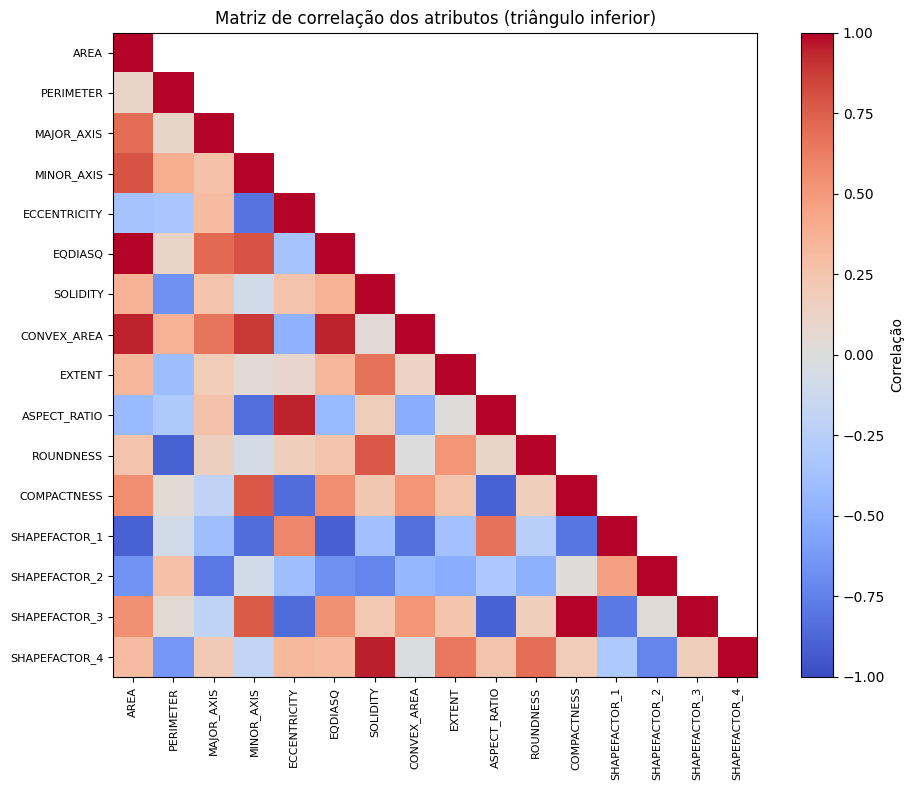

In [22]:
# Matriz de correlação dos atributos numéricos (apenas o triângulo inferior)
corr = df.drop(columns=['Class']).corr()

# Máscara para ocultar o triângulo superior (redundante, por simetria)
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_masked = np.ma.masked_array(corr, mask=mascara)

fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color='white')  # células mascaradas ficam em branco

im = ax.imshow(corr_masked, cmap=cmap, vmin=-1, vmax=1)
plt.colorbar(im, label='Correlação')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
ax.set_title('Matriz de correlação dos atributos (triângulo inferior)')
plt.tight_layout()
plt.show()

### 3.3. Codificação do alvo, separação e padronização


A variável-alvo `Class`, originalmente textual, é convertida em índices inteiros (0 e 1). Os dados são divididos em três subconjuntos — **treinamento (70%)**, **validação (15%)** e **teste (15%)** —, todos de forma estratificada, preservando a proporção das classes. A padronização (`StandardScaler`) é ajustada **exclusivamente sobre o conjunto de treinamento** e depois aplicada aos demais, evitando vazamento de informação (*data leakage*).

In [23]:
# Separação de atributos (X) e alvo (y)
X = df.drop(columns=['Class']).values.astype(np.float32)

# Codificação das classes em inteiros
classes = sorted(df['Class'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
y = df['Class'].map(class_to_idx).values.astype(np.int64)

print('Mapeamento de classes:', class_to_idx)
print('Número de atributos:', X.shape[1])

Mapeamento de classes: {'Kirmizi_Pistachio': 0, 'Siit_Pistachio': 1}
Número de atributos: 16


In [24]:
# Divisão treino (70%) / validação (15%) / teste (15%), estratificada
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print('Treino:    ', X_train.shape)
print('Validação: ', X_val.shape)
print('Teste:     ', X_test.shape)

Treino:     (1502, 16)
Validação:  (323, 16)
Teste:      (323, 16)


In [25]:
# Padronização: ajustada apenas no treino
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

In [26]:
# Criação dos DataLoaders
batch_size = 32

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=batch_size, shuffle=True)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=64)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=64)

print('Número de mini-batches de treino:', len(train_loader))

Número de mini-batches de treino: 47


## 4. Definição do modelo da rede neural


A rede é um **Perceptron Multicamadas (MLP)** composto exclusivamente por camadas densas (`nn.Linear`) e ativações não lineares (`ReLU`), **sem qualquer camada convolucional**, conforme exigido pelo projeto. A arquitetura adotada é:

- **Camada de entrada:** 16 atributos;
- **1ª camada oculta:** 32 neurônios, com ativação ReLU e *dropout* de 0,2 (regularização para mitigar sobreajuste);
- **2ª camada oculta:** 16 neurônios, com ativação ReLU;
- **Camada de saída:** 2 neurônios (um por classe).

A saída produz os *scores* (logitos) das duas classes; a conversão em probabilidades é realizada internamente pela função de perda `CrossEntropyLoss`, que combina *softmax* e entropia cruzada.

In [27]:
class MLP(nn.Module):
    def __init__(self, n_entradas=16, n_classes=2):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Linear(n_entradas, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, n_classes),
        )

    def forward(self, x):
        return self.rede(x)

model = MLP(n_entradas=X.shape[1], n_classes=len(classes)).to(device)
print(model)
print('\nTotal de parâmetros treináveis:',
      sum(p.numel() for p in model.parameters() if p.requires_grad))

MLP(
  (rede): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=2, bias=True)
  )
)

Total de parâmetros treináveis: 1106


## 5. Treinamento do modelo


Empregam-se a função de perda **Entropia Cruzada** (`CrossEntropyLoss`) e o otimizador **Adam** (taxa de aprendizado 0,001). As funções a seguir executam, respectivamente, uma época de treinamento e uma avaliação (sem cálculo de gradientes), retornando perda e acurácia médias. A avaliação no conjunto de validação ao final de cada época permite monitorar a generalização e detectar eventual sobreajuste.

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def executa_epoca(loader, treino=True):
    model.train() if treino else model.eval()
    perda_total, acertos, n = 0.0, 0, 0
    contexto = torch.enable_grad() if treino else torch.no_grad()
    with contexto:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if treino:
                optimizer.zero_grad()
            saida = model(xb)
            perda = criterion(saida, yb)
            if treino:
                perda.backward()
                optimizer.step()
            perda_total += perda.item() * len(xb)
            acertos += saida.argmax(1).eq(yb).sum().item()
            n += len(xb)
    return perda_total / n, acertos / n

In [29]:
n_epocas = 60
hist = {'perda_treino': [], 'perda_val': [], 'acc_treino': [], 'acc_val': []}

for epoca in range(1, n_epocas + 1):
    perda_tr, acc_tr = executa_epoca(train_loader, treino=True)
    perda_vl, acc_vl = executa_epoca(val_loader, treino=False)

    hist['perda_treino'].append(perda_tr)
    hist['perda_val'].append(perda_vl)
    hist['acc_treino'].append(acc_tr)
    hist['acc_val'].append(acc_vl)

    if epoca % 5 == 0 or epoca == 1:
        print(f'Época [{epoca:2d}/{n_epocas}] | '
              f'Perda treino: {perda_tr:.4f}, Acc treino: {acc_tr:.4f} | '
              f'Perda val: {perda_vl:.4f}, Acc val: {acc_vl:.4f}')

print('\nTreinamento concluído.')

Época [ 1/60] | Perda treino: 0.6475, Acc treino: 0.5646 | Perda val: 0.5288, Acc val: 0.7771
Época [ 5/60] | Perda treino: 0.2940, Acc treino: 0.8822 | Perda val: 0.3522, Acc val: 0.8514
Época [10/60] | Perda treino: 0.2854, Acc treino: 0.8795 | Perda val: 0.3413, Acc val: 0.8607
Época [15/60] | Perda treino: 0.2825, Acc treino: 0.8795 | Perda val: 0.3427, Acc val: 0.8545
Época [20/60] | Perda treino: 0.2784, Acc treino: 0.8888 | Perda val: 0.3429, Acc val: 0.8545
Época [25/60] | Perda treino: 0.2761, Acc treino: 0.8875 | Perda val: 0.3381, Acc val: 0.8483
Época [30/60] | Perda treino: 0.2754, Acc treino: 0.8881 | Perda val: 0.3432, Acc val: 0.8576
Época [35/60] | Perda treino: 0.2709, Acc treino: 0.8862 | Perda val: 0.3376, Acc val: 0.8483
Época [40/60] | Perda treino: 0.2669, Acc treino: 0.8915 | Perda val: 0.3407, Acc val: 0.8483
Época [45/60] | Perda treino: 0.2705, Acc treino: 0.8848 | Perda val: 0.3445, Acc val: 0.8514
Época [50/60] | Perda treino: 0.2652, Acc treino: 0.8881 | P

## 6. Análise de desempenho


### 6.1. Curvas de perda e de acurácia


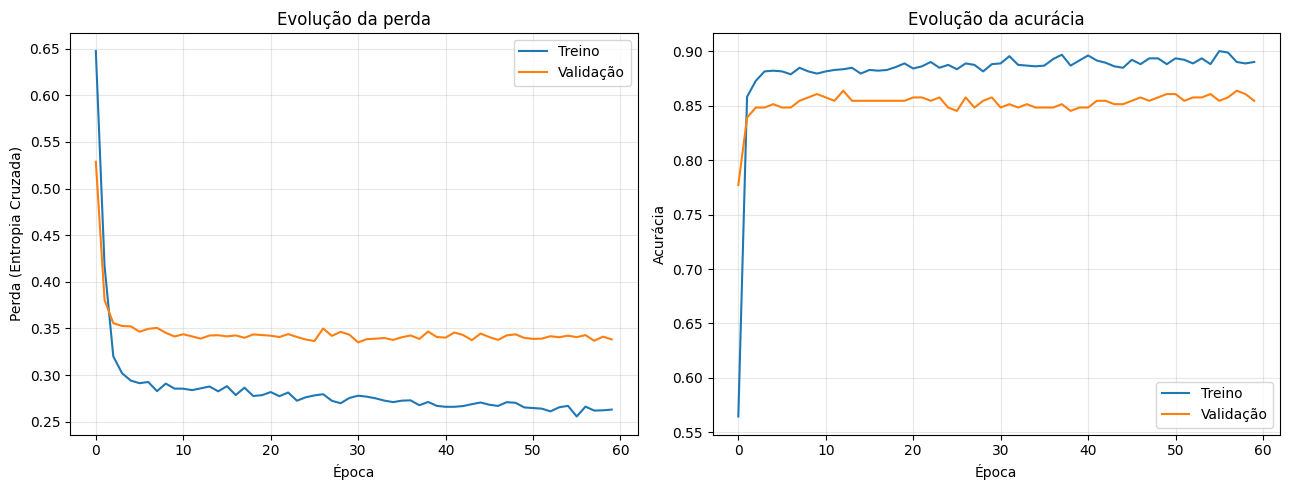

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(hist['perda_treino'], label='Treino')
ax1.plot(hist['perda_val'], label='Validação')
ax1.set_xlabel('Época')
ax1.set_ylabel('Perda (Entropia Cruzada)')
ax1.set_title('Evolução da perda')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(hist['acc_treino'], label='Treino')
ax2.plot(hist['acc_val'], label='Validação')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.set_title('Evolução da acurácia')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2. Avaliação no conjunto de teste


A avaliação final é realizada sobre o conjunto de teste, **não utilizado durante o treinamento nem para decisões de modelagem**, fornecendo uma estimativa imparcial do desempenho de generalização.

In [31]:
perda_teste, acc_teste = executa_epoca(test_loader, treino=False)
print(f'Perda no teste:    {perda_teste:.4f}')
print(f'Acurácia no teste: {acc_teste:.4f}  ({acc_teste:.2%})')

Perda no teste:    0.3466
Acurácia no teste: 0.8514  (85.14%)


### 6.3. Matriz de confusão e relatório de classificação


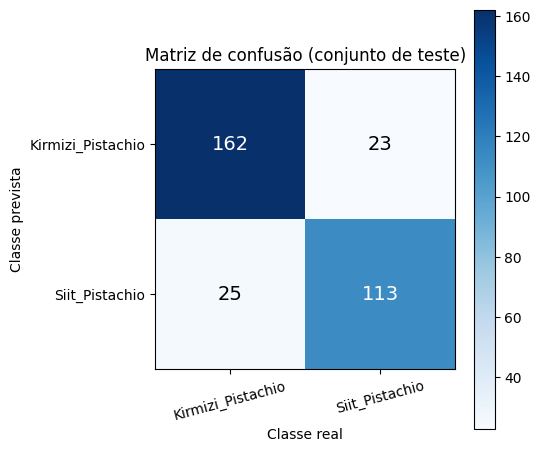

In [32]:
# Coleta das predições no conjunto de teste
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(yb.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
nomes = [idx_to_class[i] for i in range(len(classes))]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(nomes)))
ax.set_yticks(range(len(nomes)))
ax.set_xticklabels(nomes, rotation=15)
ax.set_yticklabels(nomes)
ax.set_xlabel('Classe real')
ax.set_ylabel('Classe prevista')
ax.set_title('Matriz de confusão (conjunto de teste)')
for i in range(len(nomes)):
    for j in range(len(nomes)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [33]:
# Relatório de classificação (precisão, revocação, F1 por classe)
print(classification_report(y_true, y_pred, target_names=nomes, digits=4))

                   precision    recall  f1-score   support

Kirmizi_Pistachio     0.8663    0.8757    0.8710       185
   Siit_Pistachio     0.8309    0.8188    0.8248       138

         accuracy                         0.8514       323
        macro avg     0.8486    0.8473    0.8479       323
     weighted avg     0.8512    0.8514    0.8513       323



## 7. Relato do processo e da experiência


O desenvolvimento deste projeto seguiu o fluxo típico de um problema de classificação com redes neurais. O **Pistachio Dataset** foi escolhido por ser tabular, de dimensão moderada e adequado a uma rede densa sem convolução, atendendo diretamente à restrição do projeto. A etapa inicial de exploração revelou um conjunto limpo, sem valores ausentes, com 16 atributos morfológicos e duas classes levemente desbalanceadas (cerca de 57% *Kirmizi* e 43% *Siirt*). Por essa razão, optou-se por uma divisão **estratificada** em treino, validação e teste, de modo a preservar a proporção das classes em todos os subconjuntos.

A principal dificuldade técnica esteve relacionada à **forte diferença de escala entre os atributos** — variáveis como `AREA` e `CONVEX_AREA` assumem valores na casa das dezenas de milhares, enquanto os fatores de forma são inferiores à unidade. Sem padronização, o treinamento se mostrava instável e lento, pois os atributos de maior magnitude dominavam o cálculo do gradiente. A aplicação do `StandardScaler`, ajustado exclusivamente sobre o conjunto de treinamento (para evitar vazamento de dados), resolveu esse problema e tornou a convergência rápida e estável.

Quanto ao ajuste do modelo, a arquitetura inicialmente testada, sem regularização, apresentava sinais de **leve sobreajuste**: a acurácia de treinamento crescia continuamente, enquanto a de validação estagnava e a perda de validação chegava a subir nas épocas finais. A introdução de uma camada de *dropout* (0,2) após a primeira camada oculta atenuou esse comportamento, aproximando as curvas de treino e validação. O modelo final apresenta uma diferença pequena entre a acurácia de treinamento (em torno de 89%) e a de teste (em torno de 85%), o que indica um equilíbrio satisfatório entre viés e variância, sem sobreajuste relevante.

O resultado final — acurácia de teste **superior a 85%**, portanto bem acima do limiar de 70% — foi considerado satisfatório para uma rede simples. Como possíveis aprimoramentos, poderiam ser exploradas técnicas de seleção de atributos (dado que a matriz de correlação evidencia variáveis redundantes), o ajuste sistemático de hiperparâmetros e o uso de validação cruzada para uma estimativa de desempenho mais robusta. De modo geral, a experiência reforçou a importância das etapas de pré-processamento — em especial a padronização — e do monitoramento conjunto das métricas de treino e validação como instrumento para diagnosticar e corrigir o sobreajuste.

## 8. Conclusão


Este projeto demonstrou a aplicação completa de uma rede neural densa (MLP), sem convolução, à classificação das variedades de pistache do *Pistachio Dataset*. Foram percorridas todas as etapas exigidas: carregamento e preparação dos dados, definição do modelo, treinamento e análise de desempenho com múltiplas métricas (acurácia, perda, matriz de confusão e relatório de classificação). O modelo alcançou acurácia superior a 85% no conjunto de teste, com bom equilíbrio de generalização, validando a adequação de uma arquitetura simples para um problema tabular bem estruturado.